
# CASO 4 — Impacto departamental (Operación ChasquiFest)
## Auditoría de visualización — el mapa de burbujas que confunde "más grande" con "más querido"

**Rol:** Auditor de Visualización. **Rigor:** cada afirmación se ancla en un número recalculado directamente del CSV en este notebook, con numerador y denominador declarados.

**El caso:** el comité recibió un mapa de burbujas con asistencias ABSOLUTAS por sede: Lima tiene la burbuja mayor, el
DIÁMETRO fue escalado linealmente al valor (lo que distorsiona el ÁREA) y el colormap `jet` pinta una falsa "montaña de
intensidad". El título concluye que Lima "ama más" al festival. Población, capacidad instalada y tasas normalizadas no
llegaron a la reunión — y sin ellas, el comité no puede decidir dónde reforzar seguridad, dónde ampliar alcance ni dónde
mejorar la experiencia.

**Granularidad del dataset:** 1 fila = 1 sede/departamento, año 2025 (12 sedes, 12 eventos cada una). No hay una segunda
columna de año, por lo tanto **todas** las comparaciones de este notebook son intra-2025 (periodos homólogos por
construcción; no se compara contra otro año porque el CSV no lo contiene).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle, Circle

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

CSV_PATH = '../data/caso4_impacto_departamental_chasquifest.csv'
df = pd.read_csv(CSV_PATH)

print(f"Filas: {len(df)}  |  Columnas: {len(df.columns)}")
print("Granularidad: 1 fila = 1 sede/departamento, año 2025 (12 sedes, 12 eventos/sede)")
print()
df


Filas: 12  |  Columnas: 18
Granularidad: 1 fila = 1 sede/departamento, año 2025 (12 sedes, 12 eventos/sede)



,sede_id,ciudad,departamento,macrozona,poblacion_referencial,latitud,longitud,asistentes_2025,visitantes_unicos_2025,capacidad_anual_2025,eventos_2025,reclamos_totales,reclamos_accesibilidad,costo_publico_soles,alcance_por_1000_hab,ocupacion_pct,reclamos_por_10000_asistencias,costo_por_asistente_soles
0,SED-01,Lima,Lima,Costa,10151200,-12.05,-77.04,462690,324391,556171,12,1986,477,"5,765,546.42",31.96,83.19,42.92,12.46
1,SED-02,Piura,Piura,Costa,2103100,-5.19,-80.63,246920,170054,268365,12,1546,321,"2,401,177.42",80.86,92.01,62.61,9.72
2,SED-03,Trujillo,La Libertad,Costa,2155900,-8.11,-79.03,253960,169269,297482,12,491,107,"3,988,330.43",78.51,85.37,19.33,15.70
3,SED-04,Chiclayo,Lambayeque,Costa,1361000,-6.77,-79.84,209585,157409,248547,12,397,149,"3,890,100.33",115.66,84.32,18.94,18.56
4,SED-05,Arequipa,Arequipa,Sierra,1631100,-16.40,-71.54,268001,202092,323087,12,1075,353,"3,639,108.44",123.90,82.95,40.11,13.58
5,SED-06,Cusco,Cusco,Sierra,1404000,-13.52,-71.97,281998,221678,376189,12,1946,325,"4,676,827.63",157.89,74.96,69.01,16.58
6,SED-07,Puno,Puno,Sierra,1226400,-15.84,-70.02,192791,144324,237943,12,355,85,"2,899,695.99",117.68,81.02,18.41,15.04
7,SED-08,Ayacucho,Ayacucho,Sierra,668200,-13.16,-74.22,148376,98130,176434,12,973,202,"1,947,175.32",146.86,84.10,65.58,13.12
8,SED-09,Huancayo,Junín,Sierra,1398300,-12.07,-75.21,191666,154318,230801,12,813,151,"2,625,521.24",110.36,83.04,42.42,13.70
9,SED-10,Tarapoto,San Martín,Selva,932400,-6.49,-76.36,156388,117551,169146,12,435,93,"2,762,466.84",126.07,92.46,27.82,17.66



### 0. Verificación de fórmulas ancla (nivel de fila)

Antes de rankear nada, confirmamos que las 4 tasas ya provistas en el CSV son en efecto lo que dicen ser: una
fórmula `numerador / denominador` por fila (sede), no una medida agregada opaca.


In [2]:

df['alcance_calc']   = df['visitantes_unicos_2025'] / df['poblacion_referencial'] * 1000
df['reclamos_calc']  = df['reclamos_totales'] / df['asistentes_2025'] * 10000
df['ocupacion_calc'] = df['asistentes_2025'] / df['capacidad_anual_2025'] * 100
df['costo_calc']     = df['costo_publico_soles'] / df['asistentes_2025']

checks = pd.DataFrame({
    'campo_csv': ['alcance_por_1000_hab', 'reclamos_por_10000_asistencias', 'ocupacion_pct', 'costo_por_asistente_soles'],
    'formula (num / den)': [
        'visitantes_unicos_2025 / poblacion_referencial * 1000',
        'reclamos_totales / asistentes_2025 * 10000',
        'asistentes_2025 / capacidad_anual_2025 * 100',
        'costo_publico_soles / asistentes_2025',
    ],
    'diff_max_abs': [
        (df['alcance_calc']   - df['alcance_por_1000_hab']).abs().max(),
        (df['reclamos_calc']  - df['reclamos_por_10000_asistencias']).abs().max(),
        (df['ocupacion_calc'] - df['ocupacion_pct']).abs().max(),
        (df['costo_calc']     - df['costo_por_asistente_soles']).abs().max(),
    ],
})
print(checks.to_string(index=False))
assert (checks['diff_max_abs'] < 0.01).all(), "Alguna tasa no coincide con su formula declarada (num/den)"
print("\nOK -> las 4 tasas quedan CONFIRMADAS: coinciden con su numerador/denominador declarado (diferencia < 0.01, redondeo de fuente).")


                     campo_csv                                   formula (num / den)  diff_max_abs
          alcance_por_1000_hab visitantes_unicos_2025 / poblacion_referencial * 1000          0.00
reclamos_por_10000_asistencias            reclamos_totales / asistentes_2025 * 10000          0.00
                 ocupacion_pct          asistentes_2025 / capacidad_anual_2025 * 100          0.00
     costo_por_asistente_soles                 costo_publico_soles / asistentes_2025          0.00

OK -> las 4 tasas quedan CONFIRMADAS: coinciden con su numerador/denominador declarado (diferencia < 0.01, redondeo de fuente).



---
## Pregunta 1 — Un ranking por decisión

Cada decisión del comité necesita una métrica distinta, con un **denominador distinto**. Ninguna es "la verdadera":
responden preguntas diferentes.


In [3]:

rank_volumen = (df[['ciudad','departamento','asistentes_2025']]
                .sort_values('asistentes_2025', ascending=False)
                .reset_index(drop=True))
rank_volumen.index += 1

rank_alcance = (df[['ciudad','departamento','visitantes_unicos_2025','poblacion_referencial','alcance_por_1000_hab']]
                .sort_values('alcance_por_1000_hab', ascending=False)
                .reset_index(drop=True))
rank_alcance.index += 1

rank_reclamos = (df[['ciudad','departamento','reclamos_totales','asistentes_2025','reclamos_por_10000_asistencias']]
                  .sort_values('reclamos_por_10000_asistencias', ascending=False)
                  .reset_index(drop=True))
rank_reclamos.index += 1

print("="*90)
print("RANKING 1 -- VOLUMEN  (decision: asignar personal de seguridad)")
print("metrica = asistentes_2025  |  numerador = asistencias totales 2025  |  denominador = NINGUNO (magnitud absoluta)")
print("="*90)
print(rank_volumen.head(5).to_string())

print()
print("="*90)
print("RANKING 2 -- ALCANCE TERRITORIAL  (decision: comparar penetracion / donde ampliar cobertura)")
print("metrica = alcance_por_1000_hab = visitantes_unicos_2025 / poblacion_referencial * 1000")
print("numerador = visitantes UNICOS 2025 (personas distintas)  |  denominador = poblacion_referencial")
print("="*90)
print(rank_alcance.head(5).to_string())

print()
print("="*90)
print("RANKING 3 -- CALIDAD OPERATIVA / RIESGO  (decision: priorizar mejora de experiencia; peor arriba)")
print("metrica = reclamos_por_10000_asistencias = reclamos_totales / asistentes_2025 * 10000")
print("numerador = reclamos totales  |  denominador = asistencias 2025 (NO visitantes unicos)")
print("="*90)
print(rank_reclamos.head(5).to_string())


RANKING 1 -- VOLUMEN  (decision: asignar personal de seguridad)
metrica = asistentes_2025  |  numerador = asistencias totales 2025  |  denominador = NINGUNO (magnitud absoluta)
     ciudad departamento  asistentes_2025
1      Lima         Lima           462690
2     Cusco        Cusco           281998
3  Arequipa     Arequipa           268001
4  Trujillo  La Libertad           253960
5     Piura        Piura           246920

RANKING 2 -- ALCANCE TERRITORIAL  (decision: comparar penetracion / donde ampliar cobertura)
metrica = alcance_por_1000_hab = visitantes_unicos_2025 / poblacion_referencial * 1000
numerador = visitantes UNICOS 2025 (personas distintas)  |  denominador = poblacion_referencial
     ciudad departamento  visitantes_unicos_2025  poblacion_referencial  alcance_por_1000_hab
1     Cusco        Cusco                  221678                1404000                157.89
2  Ayacucho     Ayacucho                   98130                 668200                146.86
3  Pucallpa 


**Evidencia del reordenamiento.** A continuación, la posición (1 = primero) de cada una de las 12 sedes en los tres
rankings simultáneamente.


In [4]:

df['rank_volumen']  = df['asistentes_2025'].rank(ascending=False, method='min').astype(int)
df['rank_alcance']  = df['alcance_por_1000_hab'].rank(ascending=False, method='min').astype(int)
df['rank_reclamos'] = df['reclamos_por_10000_asistencias'].rank(ascending=False, method='min').astype(int)

reorder = (df[['ciudad','asistentes_2025','rank_volumen','alcance_por_1000_hab','rank_alcance',
               'reclamos_por_10000_asistencias','rank_reclamos']]
           .sort_values('rank_volumen'))
print("Posicion de cada sede en los 3 rankings (1=primero de 12):")
print(reorder.to_string(index=False))

print()
for ciudad in ['Lima', 'Cusco']:
    r = df.loc[df.ciudad == ciudad].iloc[0]
    print(f"{ciudad}: #{r.rank_volumen} en volumen  ->  #{r.rank_alcance} en alcance  ->  #{r.rank_reclamos} en reclamos")

pob_total = df['poblacion_referencial'].sum()
asis_total = df['asistentes_2025'].sum()
lima = df.loc[df.ciudad == 'Lima'].iloc[0]
print()
print(f"Lima concentra {lima.poblacion_referencial/pob_total*100:.2f}% de la poblacion de referencia total "
      f"({lima.poblacion_referencial:,}/{pob_total:,}) pero solo {lima.asistentes_2025/asis_total*100:.2f}% de las "
      f"asistencias totales ({lima.asistentes_2025:,}/{asis_total:,}).")
no_alcanzado_pct = 100 - lima.alcance_por_1000_hab/1000*100
print(f"Alcance de Lima: {lima.alcance_por_1000_hab:.2f} por 1,000 hab. -> {no_alcanzado_pct:.2f}% de su poblacion referencial "
      f"NUNCA asistio en 2025 ({lima.poblacion_referencial - lima.visitantes_unicos_2025:,} personas).")


Posicion de cada sede en los 3 rankings (1=primero de 12):
  ciudad  asistentes_2025  rank_volumen  alcance_por_1000_hab  rank_alcance  reclamos_por_10000_asistencias  rank_reclamos
    Lima           462690             1                 31.96            12                           42.92              5
   Cusco           281998             2                157.89             1                           69.01              1
Arequipa           268001             3                123.90             5                           40.11              7
Trujillo           253960             4                 78.51            11                           19.33             10
   Piura           246920             5                 80.86            10                           62.61              3
Chiclayo           209585             6                115.66             7                           18.94             11
    Puno           192791             7                117.68             6     


### Respuesta — P1

**(a) VOLUMEN — asignar personal de seguridad**
1. **Concepto técnico:** aforo absoluto (conteo de asistencias, no de personas distintas). Mide carga operativa total a
   custodiar; no se normaliza porque la seguridad se dimensiona contra multitudes físicas reales, no contra tasas.
2. **Evidencia:** `asistentes_2025`. Numerador = asistencias 2025; **denominador = ninguno** (es una magnitud absoluta,
   no una tasa). Top 5: Lima 462,690 (#1), Cusco 281,998 (#2), Arequipa 268,001 (#3), Trujillo 253,960 (#4), Piura
   246,920 (#5).
3. **Decisión de cálculo — Tableau:** `SUM([asistentes_2025])`, con table calc `RANK(SUM([asistentes_2025]))`.
   **Partición:** ninguna (la tabla completa; granularidad = 1 fila/sede, un solo año). **Addressing:** Ciudad/Departamento
   (el ranking recorre esa dimensión). — **pandas:** `df['asistentes_2025'].rank(ascending=False)`.
4. **Límite/trade-off:** ignora la ocupación relativa del recinto. Tarapoto opera al **92.46%** de su capacidad
   (asistentes=156,388 / capacidad_anual_2025=169,146) — la ocupación **más alta** de las 12 sedes — pero por volumen
   bruto cae al puesto **#9**, recibiendo relativamente poco refuerzo si el criterio fuera solo volumen. Riesgo:
   sedes pequeñas casi llenas quedan sub-atendidas en seguridad.

**(b) TASA POBLACIONAL — comparar alcance territorial**
1. **Concepto técnico:** penetración territorial — cuántas personas *distintas* de la población de referencia fueron
   alcanzadas, normalizando por tamaño poblacional para comparar sedes de escala muy distinta.
2. **Evidencia:** `alcance_por_1000_hab = visitantes_unicos_2025 / poblacion_referencial * 1000` (CONFIRMADO,
   diff máx. 0.0043 vs. recálculo). Numerador = visitantes únicos 2025; denominador = población referencial. Top 5:
   Cusco 157.89 (221,678/1,404,000), Ayacucho 146.86 (98,130/668,200), Pucallpa 135.62 (87,911/648,200), Tarapoto
   126.07 (117,551/932,400), Arequipa 123.90 (202,092/1,631,100). Lima cae a **31.96** (324,391/10,151,200).
3. **Decisión de cálculo — Tableau:** `SUM([visitantes_unicos_2025]) / SUM([poblacion_referencial]) * 1000`, con
   `RANK(...)`. **Partición:** ninguna. **Addressing:** Ciudad/Departamento. — **pandas:**
   `(df.visitantes_unicos_2025 / df.poblacion_referencial * 1000).rank(ascending=False)`.
4. **Límite/trade-off:** premia poblaciones chicas. Pucallpa (población 648,200, la **más pequeña** de las 12) entra
   al podio de alcance, mientras Lima —con 10,151,200 hab., 15.7× la población de Pucallpa— queda relegada, aunque en
   términos absolutos deja sin cubrir a **9,826,809 personas (96.80% de su población referencial)** que nunca
   asistieron en 2025. Ese mercado sin explotar no aparece en un ranking de tasas.

**(c) TASA DE RECLAMOS — priorizar calidad operativa**
1. **Concepto técnico:** intensidad de fricción por unidad de actividad — normaliza reclamos por volumen de asistencia
   para comparar "calidad percibida" entre sedes de tamaño distinto.
2. **Evidencia:** `reclamos_por_10000_asistencias = reclamos_totales / asistentes_2025 * 10000` (CONFIRMADO, diff máx.
   0.0046). Numerador = reclamos totales; denominador = asistencias 2025 (no visitantes únicos). Top 5 peor: Cusco
   69.01 (1,946/281,998), Ayacucho 65.58 (973/148,376), Piura 62.61 (1,546/246,920), Pucallpa 54.78 (739/134,905),
   Lima 42.92 (1,986/462,690).
3. **Decisión de cálculo — Tableau:** `SUM([reclamos_totales]) / SUM([asistentes_2025]) * 10000`, con `RANK(...)`
   ordenado descendente (mayor tasa = peor). **Partición:** ninguna. **Addressing:** Ciudad/Departamento. —
   **pandas:** `(df.reclamos_totales / df.asistentes_2025 * 10000).rank(ascending=False)`.
4. **Límite/trade-off:** puede castigar sedes con **mejor cultura o mayor accesibilidad de canales de reporte**
   (más fácil quejarse → más reclamos registrados, no necesariamente peor servicio), o premiar sedes con canales
   pobres. Puno tiene la tasa más baja (18.41): no podemos afirmar causalmente que da mejor servicio — podría tener
   menos canales de reporte (asociación, no causalidad). Dato de contexto: en Cusco solo el **16.70%** de sus 1,946
   reclamos son de accesibilidad (`reclamos_accesibilidad`=325) — el porcentaje **más bajo** de las 12 sedes — lo que
   sugiere que su fricción no es solo de accesibilidad, aunque tampoco prueba causa-raíz sin investigación cualitativa
   adicional.

**Por qué los tres rankings cambian sin que ninguno sea "falso":** miden objetivos distintos con denominadores
distintos. Volumen (sin denominador) responde "¿dónde hay más gente físicamente?"; alcance (den=población) responde
"¿qué proporción del territorio se activó?"; reclamos (den=asistencias) responde "¿qué tan fricción-intensiva es la
experiencia por visita?". Lima domina el primero porque concentra el **41.05%** de la población de referencia
nacional pero solo el **17.11%** de las asistencias totales: es grande en términos absolutos pero relativamente poco
penetrada. Cusco lidera el segundo **y** es alto en el tercero al mismo tiempo — alta penetración y alta fricción no
son contradictorias, son dos caras de una sede muy demandada relativa a su tamaño.



### Figura 1 — Tarea analítica: comparación de magnitud / ranking (canal = posición)

Tres barras ordenadas, una por métrica, mismas 12 sedes. La tarea analítica de esta figura es **ranking / comparación
de magnitud**: por eso el canal usado es posición en eje (barra horizontal ordenada), el canal que Cleveland &
McGill identifican como el más preciso para juicios de magnitud — muy superior a área o color. Lima (rojo) y Cusco
(azul) se resaltan para visualizar el reordenamiento.


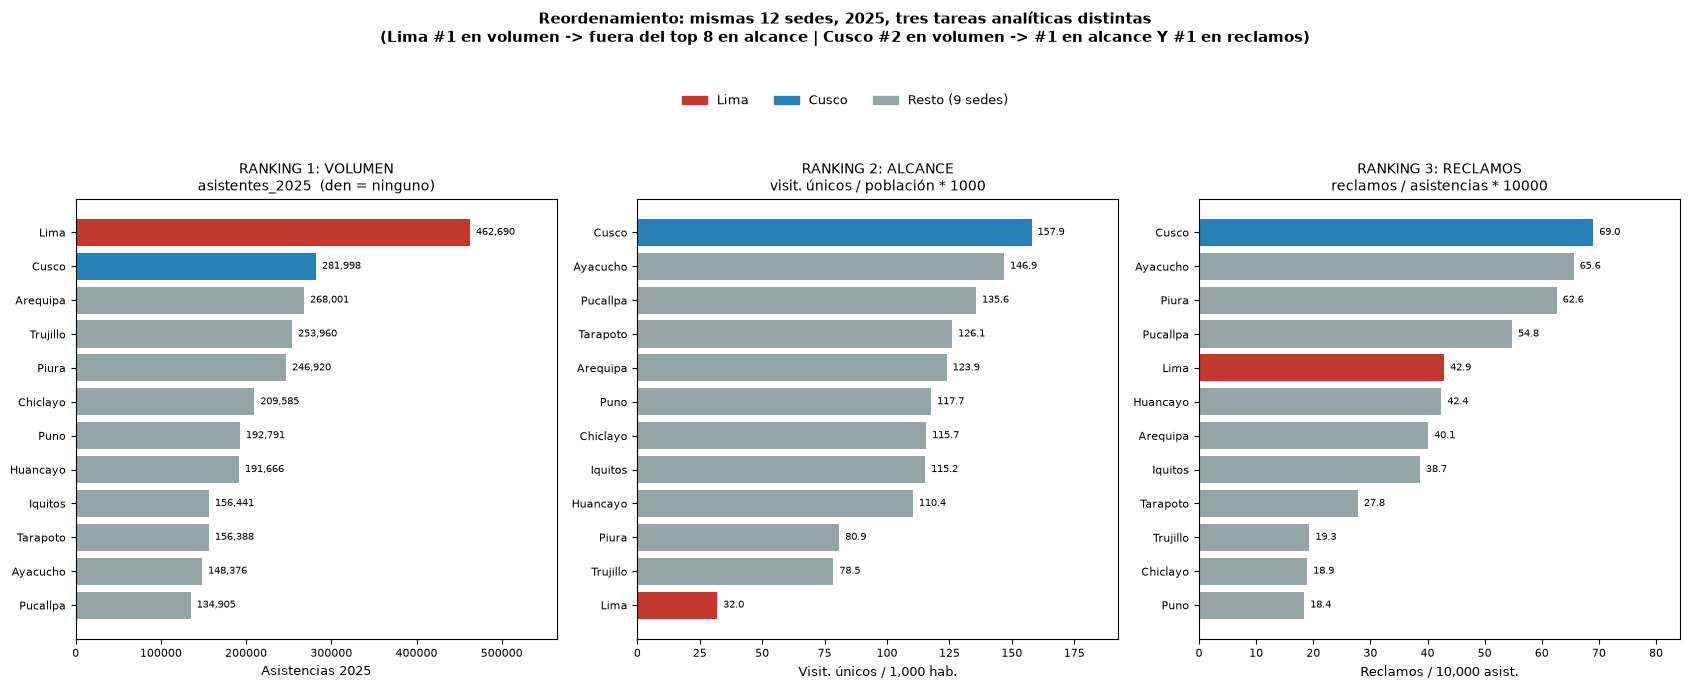

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

metrics = [
    ('asistentes_2025', 'RANKING 1: VOLUMEN\nasistentes_2025  (den = ninguno)', 'Asistencias 2025', '{:,.0f}'),
    ('alcance_por_1000_hab', 'RANKING 2: ALCANCE\nvisit. únicos / población * 1000', 'Visit. únicos / 1,000 hab.', '{:,.1f}'),
    ('reclamos_por_10000_asistencias', 'RANKING 3: RECLAMOS\nreclamos / asistencias * 10000', 'Reclamos / 10,000 asist.', '{:,.1f}'),
]

for ax, (col, title, xlabel, fmt) in zip(axes, metrics):
    d = df.sort_values(col, ascending=True)
    colors = ['#c0392b' if c == 'Lima' else '#2980b9' if c == 'Cusco' else '#95a5a6' for c in d['ciudad']]
    bars = ax.barh(d['ciudad'], d[col], color=colors)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.tick_params(labelsize=8)
    xmax = d[col].max()
    for bar, val in zip(bars, d[col]):
        ax.text(bar.get_width() + xmax * 0.015, bar.get_y() + bar.get_height() / 2,
                 fmt.format(val), va='center', fontsize=7)
    ax.set_xlim(0, xmax * 1.22)

fig.legend(handles=[Patch(color='#c0392b', label='Lima'),
                     Patch(color='#2980b9', label='Cusco'),
                     Patch(color='#95a5a6', label='Resto (9 sedes)')],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=9, frameon=False)
fig.suptitle('Reordenamiento: mismas 12 sedes, 2025, tres tareas analíticas distintas\n'
             '(Lima #1 en volumen -> fuera del top 8 en alcance | Cusco #2 en volumen -> #1 en alcance Y #1 en reclamos)',
             y=1.14, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()



---
## Pregunta 2 — Mapa o barra

### Respuesta — P2

**1. Concepto técnico:** dos preguntas distintas exigen dos tareas analíticas distintas, y cada tarea exige un tipo
de gráfico distinto.
- **(a) "¿DÓNDE?" → mapa — tarea analítica: localización geográfica / distribución espacial.** Usa
  `latitud`/`longitud` para posicionar cada sede en su ubicación real.
  - **Símbolos proporcionales** (bubble map) cuando la variable es un **conteo/volumen absoluto** (`asistentes_2025`):
    el tamaño del símbolo codifica magnitud sin inflar el área del polígono territorial que ya de por sí varía por
    departamento.
  - **Coroplético NORMALIZADO** (relleno de área) reservado para **tasas** por población o por actividad
    (`alcance_por_1000_hab`, `reclamos_por_10000_asistencias`, `ocupacion_pct`): el color debe representar algo *por
    unidad* de esa área/población, no un conteo bruto.
- **(b) "¿QUIÉN LIDERA Y POR CUÁNTO?" → barra ordenada — tarea analítica: ranking / comparación de magnitud (canal =
  posición en eje).** Ordenar descendente por la métrica elegida; eje corto = categoría (sede), eje largo = valor;
  etiquetas numéricas directas para lectura exacta (ver Figura 1).

**2. Evidencia:** por qué un coroplético de CONTEOS BRUTOS repite el mapa de población, y los dos titulares —ambos
ciertos— que compiten por la atención del comité.
- Si se pintara el departamento de Lima con el color más intenso solo por tener 462,690 asistentes, el mapa
  terminaría mostrando "dónde vive más gente", no "dónde el festival tuvo más impacto relativo". Lima tiene
  10,151,200 habitantes = **41.05%** de la población de referencia total (10,151,200/24,729,200); cualquier conteo
  bruto (asistentes, reclamos_totales, costo_publico_soles) se correlaciona mecánicamente con población, y las áreas
  grandes/pobladas "ganan" siempre en un coroplético de conteos, sin importar la variable.
- **VOLUMEN:** *"Lima concentra 462,690 asistencias, el mayor aforo"* (Ranking 1, P1a).
- **ALCANCE:** *"Cusco alcanza 158 visitantes por mil habitantes, el mayor alcance por habitante"* (Ranking 2, P1b).

**3. Decisión (asignaciones):** cada titular apunta a un recurso distinto del comité — no son intercambiables.
- **VOLUMEN → reforzar personal de seguridad y logística de multitudes en Lima** (Pregunta 1a): la decisión responde
  a carga física absoluta, sin denominador.
- **ALCANCE → estudiar la experiencia/calidad de servicio en Cusco** (Pregunta 1c), no necesariamente expandir
  infraestructura física: la decisión responde a penetración relativa a la población, no a volumen.
- Ambos titulares son ciertos simultáneamente porque responden preguntas distintas (ver cierre de P1); llevan a
  asignaciones de recursos distintas: seguridad/logística de multitudes a Lima (volumen absoluto), estudio de
  experiencia/servicio a Cusco (intensidad relativa a su población).

**4. Límite (caveat):** una tasa alta no es evidencia de causa ni de afecto — el mismo error que decir "Cusco ama
más". `ocupacion_pct` de Cusco es **74.96%**, la **más baja** de las 12 sedes — así que el alto alcance y la alta
tasa de reclamos de Cusco (**69.01**, Pregunta 1c) **no** se explican por saturación física del recinto (no está
"lleno"); apuntan más bien a gestión de flujos, servicios o accesibilidad, que solo una investigación cualitativa
adicional podría confirmar. "Mayor alcance por habitante" describe una **tasa de penetración territorial**, no un
sentimiento de apego: inferir "arraigo" o "amor" a partir de `alcance_por_1000_hab` cometería el mismo salto
lógico (tasa → causa/afecto) que el titular original del mapa de burbujas.



---
## Pregunta 3 — Área, color y acceso


In [6]:

val_lima = df.loc[df.ciudad == 'Lima', 'asistentes_2025'].item()
val_puca = df.loc[df.ciudad == 'Pucallpa', 'asistentes_2025'].item()
r_valor = val_lima / val_puca

print(f"asistentes_2025 Lima = {val_lima:,}  |  asistentes_2025 Pucallpa = {val_puca:,}")
print(f"razon de VALOR (r) = {r_valor:.4f}x")
print()
print("Si el DIAMETRO se escala linealmente al valor (el error del mapa original):")
print(f"  razon de DIAMETROS = r = {r_valor:.4f}x")
print(f"  razon de AREAS     = r^2 = {r_valor**2:.4f}x   <-- lo que el ojo integra al leer un circulo")
print(f"  sobre-representacion visual extra = r^2 / r = {r_valor**2/r_valor:.4f}x  (exactamente = r)")
print()
print("Correccion: escalar por AREA, es decir diametro ∝ sqrt(valor):")
print(f"  razon de DIAMETROS = sqrt(r) = {np.sqrt(r_valor):.4f}x")
print(f"  razon de AREAS     = (sqrt(r))^2 = {r_valor:.4f}x  <-- coincide EXACTAMENTE con la razon real de asistencias")


asistentes_2025 Lima = 462,690  |  asistentes_2025 Pucallpa = 134,905
razon de VALOR (r) = 3.4297x

Si el DIAMETRO se escala linealmente al valor (el error del mapa original):
  razon de DIAMETROS = r = 3.4297x
  razon de AREAS     = r^2 = 11.7632x   <-- lo que el ojo integra al leer un circulo
  sobre-representacion visual extra = r^2 / r = 3.4297x  (exactamente = r)

Correccion: escalar por AREA, es decir diametro ∝ sqrt(valor):
  razon de DIAMETROS = sqrt(r) = 1.8520x
  razon de AREAS     = (sqrt(r))^2 = 3.4297x  <-- coincide EXACTAMENTE con la razon real de asistencias



1. **Concepto técnico:** el error clásico de "burbuja mal escalada". Si el **DIÁMETRO** se escala linealmente al
   valor, el **ÁREA** —lo que el ojo realmente integra al leer un círculo (Cleveland & McGill; Stevens)— crece con el
   **cuadrado** del valor, exagerando visualmente las diferencias.
2. **Evidencia con números reales:** Lima (462,690 asistentes) vs. Pucallpa (134,905 asistentes), razón de valores
   **r = 3.4297×**. Con diámetro ∝ valor: razón de diámetros = 3.43×, pero razón de **áreas** = 3.43² = **11.76×**.
   El área de la burbuja de Lima aparece **11.76×** más grande que la de Pucallpa aunque el dato real es solo
   **3.43×** mayor — una sobre-representación visual adicional de exactamente 3.43× (r²/r = r).
3. **Decisión de corrección:** escalar por **ÁREA**, no por diámetro: área ∝ valor ⟹ **diámetro ∝ √valor**. Con esta
   corrección, razón de diámetros = √3.43 = **1.85×**, razón de áreas = 1.85² = **3.43×** = coincide exactamente con
   la razón real. **Tableau:** en el estante *Size*, Tableau ya escala por defecto el **área** del símbolo (no el
   diámetro) al soltar un campo continuo — el error típicamente ocurre en herramientas/código que fijan
   `markersize`/`radius` de forma lineal. **pandas/matplotlib:** usar `s = k * valor` en `plt.scatter` (matplotlib
   interpreta `s` como área en puntos², por lo que `s = k*valor` ya es correcto); el error equivalente sería
   `markersize = k*valor` en `plt.plot`, porque `markersize` es un diámetro lineal.
4. **Límite/trade-off:** incluso corregido por área, el ojo humano **subestima** áreas grandes (compresión de
   Stevens, exponente ≈0.7 para área), así que ningún bubble map da lectura cuantitativa exacta — por eso debe
   acompañarse siempre de una etiqueta numérica directa o de una barra ordenada (canal de posición) para lectura
   precisa.

**Reemplazo de colormap:** `jet` no es perceptualmente uniforme — su luminancia no es monótona, crea **falsos
bordes**/bandas de contorno que no corresponden a discontinuidades reales en los datos, y no es legible en escala de
grises ni amigable para daltonismo rojo-verde (deuteranopía/protanopía). Reemplazo: **viridis** (o **cividis**,
optimizado específicamente para deuteranopía) — luminancia monótonamente creciente, perceptualmente uniforme en
CIELAB, legible en escala de grises.

**≥2 canales redundantes** (mantienen la lectura con daltonismo o en escala de grises, sin depender del color):
1. **Etiqueta numérica directa** sobre cada símbolo (ej. "Cusco 158") — lectura exacta sin decodificar color ni área.
2. **Tamaño/área del símbolo** como canal redundante con el color — ordena visualmente sin necesitar distinguir tonos.
3. (Añadido en la Figura 2) **Borde/anillo distintivo** (grosor + color de contorno) para marcar sedes que superan un
   umbral de riesgo — un tercer canal binario, legible incluso en escala de grises por el grosor del trazo.



### Figura 2 — Demostración de la distorsión diámetro-vs-área y su corrección

**Panel A** (tarea: comparación literal de dos círculos): Lima vs. Pucallpa bajo escalado incorrecto (diámetro∝valor)
y corregido (área∝valor). **Panel B** (tarea: localización geográfica, réplica del mapa original defectuoso):
símbolos con diámetro∝valor + colormap `jet`. **Panel C** (tarea: localización geográfica, versión corregida):
símbolos con área∝`asistentes_2025`, color=`viridis` sobre `alcance_por_1000_hab`, más 2 canales redundantes
(etiqueta numérica + borde rojo grueso para sedes con `reclamos_por_10000_asistencias` por encima de la mediana).


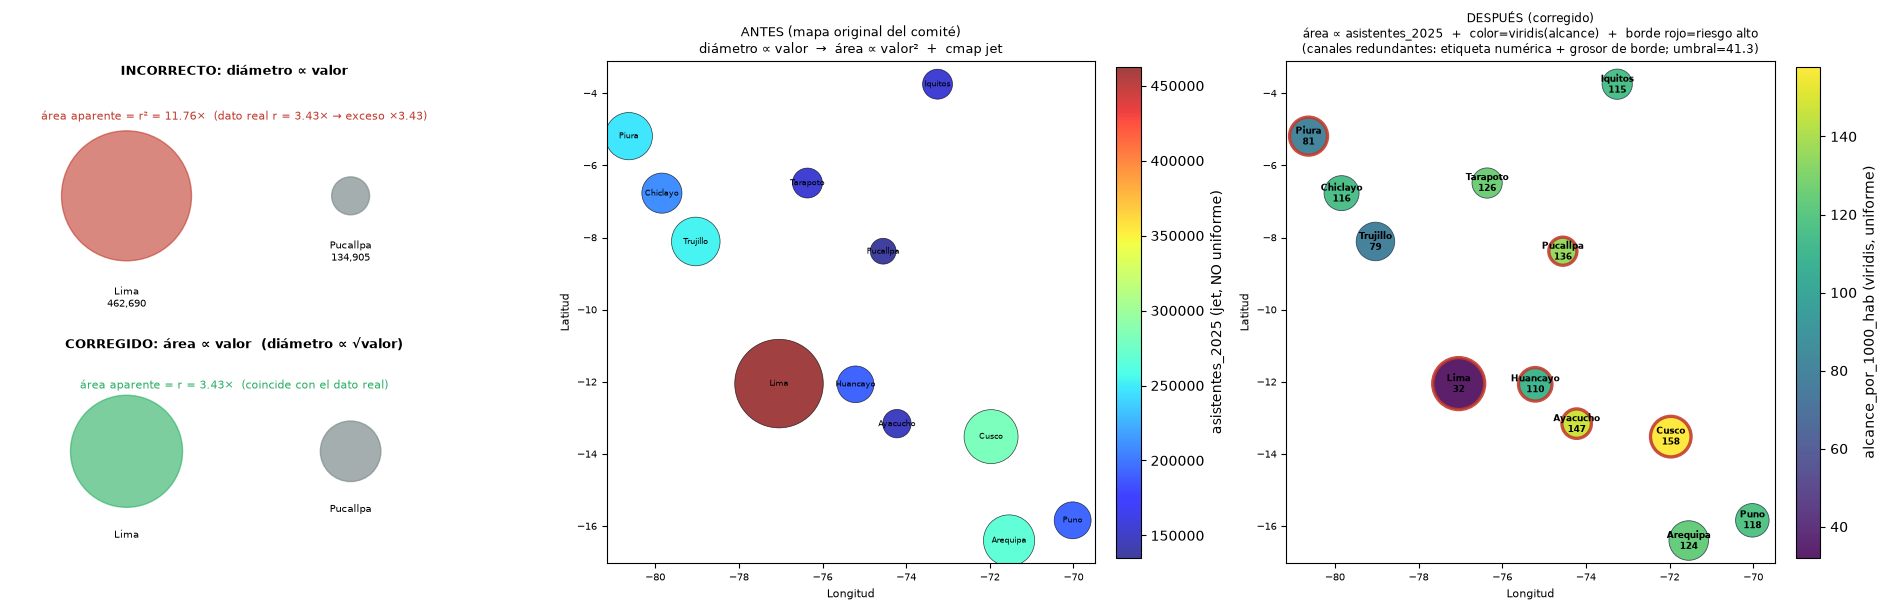

In [7]:

fig = plt.figure(figsize=(19, 6.2))
gs = fig.add_gridspec(1, 3, width_ratios=[0.85, 1, 1])

# ---------- Panel A: literal circle comparison ----------
ax0 = fig.add_subplot(gs[0])
ax0.set_xlim(0, 1); ax0.set_ylim(-0.06, 1.06); ax0.axis('off')
ax0.set_aspect('equal')

# --- top block: INCORRECTO (diametro ~ valor) ---
cy_top = 0.76
max_r = 0.145
ax0.text(0.5, 1.03, 'INCORRECTO: diámetro ∝ valor', ha='center', fontsize=9.5, fontweight='bold')
ax0.text(0.5, 0.93, f'área aparente = r² = {r_valor**2:.2f}×  (dato real r = {r_valor:.2f}× → exceso ×{r_valor:.2f})',
         ha='center', fontsize=7.6, color='#c0392b')
ax0.add_patch(Circle((0.26, cy_top), max_r, color='#c0392b', alpha=0.60))
ax0.add_patch(Circle((0.76, cy_top), max_r / r_valor, color='#7f8c8d', alpha=0.70))
ax0.text(0.26, cy_top - max_r - 0.055, f'Lima\n{val_lima:,.0f}', ha='center', va='top', fontsize=7.3)
ax0.text(0.76, cy_top - max_r / r_valor - 0.055, f'Pucallpa\n{val_puca:,.0f}', ha='center', va='top', fontsize=7.3)

# --- bottom block: CORREGIDO (area ~ valor) ---
cy_bot = 0.19
max_r2 = 0.125
ax0.text(0.5, 0.42, 'CORREGIDO: área ∝ valor  (diámetro ∝ √valor)', ha='center', fontsize=9.5, fontweight='bold')
ax0.text(0.5, 0.33, f'área aparente = r = {r_valor:.2f}×  (coincide con el dato real)',
         ha='center', fontsize=7.6, color='#27ae60')
ax0.add_patch(Circle((0.26, cy_bot), max_r2, color='#27ae60', alpha=0.60))
ax0.add_patch(Circle((0.76, cy_bot), max_r2 / np.sqrt(r_valor), color='#7f8c8d', alpha=0.70))
ax0.text(0.26, cy_bot - max_r2 - 0.05, 'Lima', ha='center', va='top', fontsize=7.3)
ax0.text(0.76, cy_bot - max_r2 / np.sqrt(r_valor) - 0.05, 'Pucallpa', ha='center', va='top', fontsize=7.3)

# ---------- Panel B: WRONG map (replica del original) ----------
ax1 = fig.add_subplot(gs[1])
s_wrong = (df['asistentes_2025'] / 1000) ** 2 * 0.019  # area ~ valor^2  =>  diametro ~ valor (el error original)
sc1 = ax1.scatter(df['longitud'], df['latitud'], s=s_wrong, c=df['asistentes_2025'],
                   cmap='jet', alpha=0.75, edgecolors='k', linewidths=0.5)
for _, row in df.iterrows():
    ax1.annotate(row['ciudad'], (row['longitud'], row['latitud']), fontsize=6, ha='center', va='center')
ax1.set_title('ANTES (mapa original del comité)\ndiámetro ∝ valor  →  área ∝ valor²  +  cmap jet', fontsize=9.5)
ax1.set_xlabel('Longitud', fontsize=8); ax1.set_ylabel('Latitud', fontsize=8)
ax1.tick_params(labelsize=7)
plt.colorbar(sc1, ax=ax1, label='asistentes_2025 (jet, NO uniforme)', fraction=0.046, pad=0.04)

# ---------- Panel C: CORRECTED map ----------
ax2 = fig.add_subplot(gs[2])
s_correct = df['asistentes_2025'] / df['asistentes_2025'].max() * 1400  # area ~ valor (correcto)
umbral = df['reclamos_por_10000_asistencias'].median()
high_risk = df['reclamos_por_10000_asistencias'] > umbral
edgecolors = np.where(high_risk, '#c0392b', '#2c3e50')
linewidths = np.where(high_risk, 2.4, 0.6)
sc2 = ax2.scatter(df['longitud'], df['latitud'], s=s_correct, c=df['alcance_por_1000_hab'],
                   cmap='viridis', alpha=0.88, edgecolors=edgecolors, linewidths=linewidths)
for _, row in df.iterrows():
    ax2.annotate(f"{row['ciudad']}\n{row['alcance_por_1000_hab']:.0f}",
                 (row['longitud'], row['latitud']), fontsize=6.3, ha='center', va='center', fontweight='bold')
ax2.set_title('DESPUÉS (corregido)\nárea ∝ asistentes_2025  +  color=viridis(alcance)  +  borde rojo=riesgo alto\n'
              f'(canales redundantes: etiqueta numérica + grosor de borde; umbral={umbral:.1f})', fontsize=8.7)
ax2.set_xlabel('Longitud', fontsize=8); ax2.set_ylabel('Latitud', fontsize=8)
ax2.tick_params(labelsize=7)
plt.colorbar(sc2, ax=ax2, label='alcance_por_1000_hab (viridis, uniforme)', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



---
## Pregunta 4 — Dashboard de decisión

Primero calculamos los 4 KPI nacionales (2025, agregados como **ratio-de-sumas**, no promedio-de-tasas, para evitar
el sesgo de ponderación tipo Simpson) y sus benchmarks internos (mediana de las 12 sedes, único "periodo" disponible
en el CSV).


In [8]:

tot_asis = df['asistentes_2025'].sum()
tot_cap  = df['capacidad_anual_2025'].sum()
tot_costo = df['costo_publico_soles'].sum()
tot_reclamos = df['reclamos_totales'].sum()
tot_visit = df['visitantes_unicos_2025'].sum()
tot_pob = df['poblacion_referencial'].sum()

ocup_nacional = tot_asis / tot_cap * 100
costo_nacional = tot_costo / tot_asis
reclamos_nacional = tot_reclamos / tot_asis * 10000
alcance_nacional = tot_visit / tot_pob * 1000

med_costo = df['costo_por_asistente_soles'].median()
med_reclamos = df['reclamos_por_10000_asistencias'].median()
med_alcance = df['alcance_por_1000_hab'].median()

print("=== KPI 1 RESULTADO: asistentes_2025 (total nacional, 2025) ===")
print(f"  valor = {tot_asis:,} asistencias  |  capacidad instalada total = {tot_cap:,}")
print(f"  ocupacion agregada (SUM/SUM) = {ocup_nacional:.2f}%  "
      f"(vs. promedio simple de ocupacion_pct por sede = {df['ocupacion_pct'].mean():.2f}%  <- OJO: no es lo mismo)")
print(f"  meta declarada (asuncion, no viene en el CSV): ocupacion agregada >= 85%  ->  "
      f"brecha = {ocup_nacional - 85:.2f} pp  ->  estado: {'VERDE' if ocup_nacional>=85 else 'AMARILLO/ALERTA'}")

print()
print("=== KPI 2 EFICIENCIA: costo_por_asistente_soles (nacional agregado, 2025) ===")
print(f"  valor = SUM(costo_publico_soles)/SUM(asistentes_2025) = S/ {costo_nacional:.2f}")
print(f"  mediana de las 12 sedes = S/ {med_costo:.2f}  |  min = Piura S/ {df['costo_por_asistente_soles'].min():.2f}  "
      f"|  max = Chiclayo S/ {df['costo_por_asistente_soles'].max():.2f}")
print(f"  meta declarada: <= mediana de sedes (S/ {med_costo:.2f})  ->  "
      f"brecha = {(costo_nacional-med_costo)/med_costo*100:+.2f}%  ->  estado: {'VERDE' if costo_nacional<=med_costo else 'ROJO'}")

print()
print("=== KPI 3 RIESGO: reclamos_por_10000_asistencias (nacional agregado, 2025) ===")
print(f"  valor = SUM(reclamos_totales)/SUM(asistentes_2025)*10000 = {reclamos_nacional:.2f}")
print(f"  mediana de las 12 sedes = {med_reclamos:.2f}")
print(f"  meta declarada: <= mediana de sedes ({med_reclamos:.2f})  ->  "
      f"brecha = {(reclamos_nacional-med_reclamos)/med_reclamos*100:+.2f}%  ->  estado: {'VERDE' if reclamos_nacional<=med_reclamos else 'ROJO/ALERTA'}")
criticas = df.loc[df['reclamos_por_10000_asistencias'] > 50, ['ciudad','reclamos_por_10000_asistencias']].sort_values('reclamos_por_10000_asistencias', ascending=False)
print(f"  sedes en zona critica (tasa > 50): {list(zip(criticas.ciudad, criticas.reclamos_por_10000_asistencias.round(2)))}")

print()
print("=== KPI 4 ALCANCE/EQUIDAD: alcance_por_1000_hab (nacional agregado, 2025) ===")
print(f"  valor = SUM(visitantes_unicos_2025)/SUM(poblacion_referencial)*1000 = {alcance_nacional:.2f}")
print(f"  mediana de las 12 sedes = {med_alcance:.2f}  <- el agregado nacional (ponderado por poblacion de Lima, "
      f"que es enorme y de bajo alcance) queda MUY por debajo de la mediana no ponderada")
print(f"  meta declarada: >= mediana de sedes ({med_alcance:.2f})  ->  "
      f"brecha = {(alcance_nacional-med_alcance)/med_alcance*100:+.2f}%  ->  estado: ROJO")


=== KPI 1 RESULTADO: asistentes_2025 (total nacional, 2025) ===
  valor = 2,703,721 asistencias  |  capacidad instalada total = 3,222,747
  ocupacion agregada (SUM/SUM) = 83.89%  (vs. promedio simple de ocupacion_pct por sede = 84.75%  <- OJO: no es lo mismo)
  meta declarada (asuncion, no viene en el CSV): ocupacion agregada >= 85%  ->  brecha = -1.11 pp  ->  estado: AMARILLO/ALERTA

=== KPI 2 EFICIENCIA: costo_por_asistente_soles (nacional agregado, 2025) ===
  valor = SUM(costo_publico_soles)/SUM(asistentes_2025) = S/ 14.03
  mediana de las 12 sedes = S/ 13.64  |  min = Piura S/ 9.72  |  max = Chiclayo S/ 18.56
  meta declarada: <= mediana de sedes (S/ 13.64)  ->  brecha = +2.84%  ->  estado: ROJO

=== KPI 3 RIESGO: reclamos_por_10000_asistencias (nacional agregado, 2025) ===
  valor = SUM(reclamos_totales)/SUM(asistentes_2025)*10000 = 42.02
  mediana de las 12 sedes = 41.27
  meta declarada: <= mediana de sedes (41.27)  ->  brecha = +1.83%  ->  estado: ROJO/ALERTA
  sedes en zona c


### Respuesta — P4

**Layout fijo 1280×720 px** (ver Figura 3, wireframe):
- **Fila 1 (título-pregunta):** *"¿Dónde reforzamos seguridad, ampliamos alcance o mejoramos experiencia? — Impacto
  departamental ChasquiFest 2025"*.
- **Fila 2 (franja de KPI, 4 tarjetas):** Resultado | Eficiencia | Riesgo | Alcance/Equidad, cada una con valor +
  comparación/meta + estado semáforo (detalle abajo).
- **Fila 3 — vista principal (izquierda, ~800px):** mapa de símbolos proporcionales (área ∝ `asistentes_2025`,
  color = viridis sobre `alcance_por_1000_hab`) — tarea: localización geográfica (P2a). **Soporte (derecha, ~450px):**
  barra ordenada configurable (volumen / alcance / reclamos) — tarea: ranking (P2b/Fig.1).
- **Fila 4 (panel de insights):** 3 bullets con números que resumen el giro analítico (Lima 41% población / 17%
  asistencias / alcance 32; Cusco #1 alcance y #1 reclamos con ocupación 74.96%, no es saturación física; 4 sedes en
  zona crítica de reclamos).
- **Fila 5 (pie metodológico):** fuente = `caso4_impacto_departamental_chasquifest.csv`, periodo = 2025, granularidad
  = 1 fila/sede (12 sedes), fórmulas de cada tasa con numerador/denominador.

**Los 4 KPI, con roles distintos y su acción/decisión asociada:**

| Rol | KPI | Fórmula (Tableau) | pandas | Valor 2025 (num/den) | Meta (declarada) | Estado | Acción / decisión |
|---|---|---|---|---|---|---|---|
| RESULTADO | `ocupación agregada` (asistentes_2025 / capacidad_anual_2025) | `SUM([asistentes_2025])/SUM([capacidad_anual_2025])*100` | `df.asistentes_2025.sum()/df.capacidad_anual_2025.sum()*100` | 83.89% (num=2,703,721 / den=3,222,747) | ocup. agregada ≥ 85% | AMARILLO (−1.11 pp) | Revisar programación y franjas horarias en sedes con capacidad ociosa para cerrar la brecha de −1.11 pp hacia la meta. |
| EFICIENCIA | `costo_por_asistente_soles` | `SUM([costo_publico_soles])/SUM([asistentes_2025])` | `df.costo_publico_soles.sum()/df.asistentes_2025.sum()` | S/ 14.03 | ≤ mediana sedes S/ 13.64 | ROJO (+2.84%) | Auditar y renegociar costos logísticos en las sedes sobre la mediana (máx. Chiclayo) para converger a S/ 13.64/asistente. |
| RIESGO | `reclamos_por_10000_asistencias` | `SUM([reclamos_totales])/SUM([asistentes_2025])*10000` | `df.reclamos_totales.sum()/df.asistentes_2025.sum()*10000` | 42.02 | ≤ mediana sedes 41.27 | ROJO/ALERTA (+1.83%) | Reforzar atención al público y protocolos de accesibilidad en Cusco, Ayacucho, Piura y Pucallpa (zona crítica >50; ver tarjeta abajo). |
| ALCANCE/EQUIDAD | `alcance_por_1000_hab` | `SUM([visitantes_unicos_2025])/SUM([poblacion_referencial])*1000` | `df.visitantes_unicos_2025.sum()/df.poblacion_referencial.sum()*1000` | 79.58 | ≥ mediana sedes 116.67 | ROJO (−31.79%) | Priorizar campañas de difusión y nuevas franjas/sedes en departamentos bajo la mediana de alcance (brecha −31.79%). |

*(Las metas de "mediana de las 12 sedes" son un benchmark interno declarado por este análisis — el CSV no trae una
meta oficial del comité; se documenta como límite explícito, no se inventa un objetivo externo.)*

**Nota técnica (evita el sesgo de "promedio de promedios"):** el agregado nacional se calcula como **ratio de sumas**
(`SUM(num)/SUM(den)`), no como promedio simple de las tasas por sede. Ejemplo: ocupación agregada = 83.89% vs.
promedio simple de `ocupacion_pct` = 84.75% — difieren porque el promedio simple pondera igual a Pucallpa (capacidad
146,046) que a Lima (capacidad 556,171). En Tableau esto se expresa con un LOD fijo:
`{FIXED : SUM([reclamos_totales])/SUM([asistentes_2025])*10000}` (una constante nacional repetible en cada fila),
en contraste con `AVG([reclamos_por_10000_asistencias])` (promedio de tasas, **no equivalente**).

**Tarjeta completa (ejemplo: RIESGO, la más ligada a "seguridad/experiencia"):**
- **Valor:** 42.02
- **Unidad:** reclamos por cada 10,000 asistencias
- **Periodo:** 2025 (año completo, 12 eventos por sede; único periodo disponible en el CSV — no se compara con otro
  año)
- **Segmento:** las 12 sedes/departamentos (agregado nacional = SUM/SUM)
- **Comparación/meta:** mediana de sedes = 41.27 (línea de referencia); meta operativa propuesta ≤ 40.00 (declarada
  por este análisis para fines de la tarjeta — límite explícito, no viene en el CSV)
- **Estado:** ícono semáforo ROJO/ÁMBAR (por encima de meta y de la mediana; 4 sedes en zona crítica >50: Cusco
  69.01, Ayacucho 65.58, Piura 62.61, Pucallpa 54.78)
- **Acción:** asignar equipos de atención al público y revisar protocolos de accesibilidad en Cusco, Ayacucho, Piura
  y Pucallpa, en ese orden de prioridad (orden = magnitud de la tasa, no del volumen absoluto).

**Jerarquía visual / proximidad / similitud (lectura en <60s):** tamaño de fuente descendente título > valor-KPI >
etiqueta; cada tarjeta agrupa valor+meta+estado en un solo bloque con espaciado uniforme (proximidad); las 4
tarjetas comparten tipografía y fondo neutro (similitud), con el color de estado (semáforo) como **único** acento
cromático variable — el ojo va directo a los 2 rojos y 1 ámbar antes de leer cualquier número.

### Bitácora (5 frases)
1. **Lectura inicial (≤15 palabras):** *"Lima domina el festival; hay que reforzar Lima."* (8 palabras)
2. **KPI decisor:** RESULTADO — ocupación agregada nacional = `SUM(asistentes_2025)/SUM(capacidad_anual_2025)*100`,
   periodo 2025, segmento = 12 sedes, meta ≥85% → valor real 83.89%.
3. **Giro analítico:** al normalizar por población (`alcance_por_1000_hab`) y por asistencia
   (`reclamos_por_10000_asistencias`), Cusco y Ayacucho emergen como focos de intensidad y fricción que el mapa de
   burbujas absolutas escondía detrás del tamaño de Lima.
4. **Lectura revisada (≤15 palabras):** *"Lima requiere volumen; Cusco y Ayacucho requieren calidad de experiencia."*
   (10 palabras)
5. **Consecuencia:** el comité reasigna presupuesto: seguridad/logística escalan con volumen en Lima, mientras
   personal de atención y accesibilidad se refuerzan en Cusco, Ayacucho, Piura y Pucallpa según su tasa de reclamos,
   no según su tamaño.


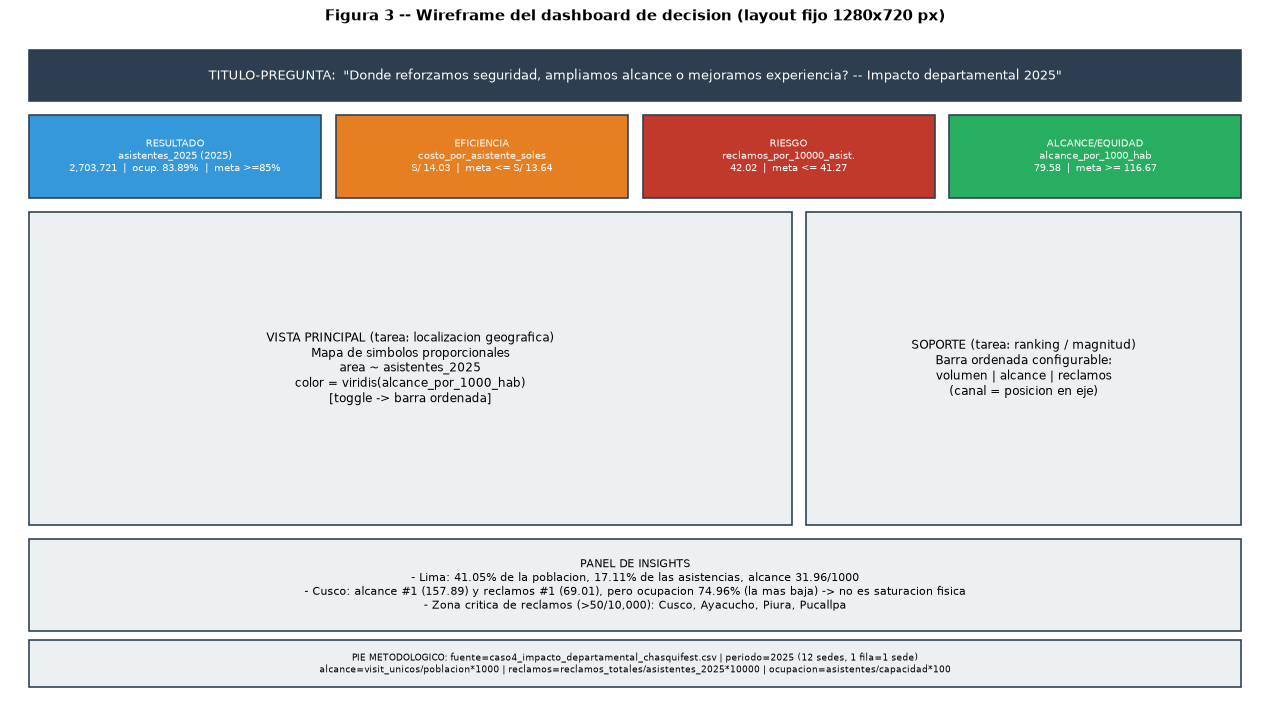

In [9]:

fig3, ax = plt.subplots(figsize=(1280/96, 720/96), dpi=96)
ax.set_xlim(0, 1280); ax.set_ylim(0, 720); ax.invert_yaxis(); ax.axis('off')

def box(x, y, w, h, label, color='#ecf0f1', fontsize=8.5, textcolor='black'):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor='#2c3e50', linewidth=1.2))
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=fontsize, color=textcolor)

box(20, 15, 1240, 55,
    'TITULO-PREGUNTA:  "Donde reforzamos seguridad, ampliamos alcance o mejoramos experiencia? -- Impacto departamental 2025"',
    color='#2c3e50', fontsize=9.5, textcolor='white')

kpi_gap = 15
kpi_w = (1240 - 3 * kpi_gap) / 4
kpi_specs = [
    ('RESULTADO\nasistentes_2025 (2025)\n2,703,721  |  ocup. 83.89%  |  meta >=85%', '#3498db'),
    ('EFICIENCIA\ncosto_por_asistente_soles\nS/ 14.03  |  meta <= S/ 13.64', '#e67e22'),
    ('RIESGO\nreclamos_por_10000_asist.\n42.02  |  meta <= 41.27', '#c0392b'),
    ('ALCANCE/EQUIDAD\nalcance_por_1000_hab\n79.58  |  meta >= 116.67', '#27ae60'),
]
for i, (label, color) in enumerate(kpi_specs):
    box(20 + i * (kpi_w + kpi_gap), 85, kpi_w, 90, label, color=color, fontsize=7.3, textcolor='white')

box(20, 190, 780, 340,
    'VISTA PRINCIPAL (tarea: localizacion geografica)\nMapa de simbolos proporcionales\narea ~ asistentes_2025\ncolor = viridis(alcance_por_1000_hab)\n[toggle -> barra ordenada]',
    fontsize=9)
box(815, 190, 445, 340,
    'SOPORTE (tarea: ranking / magnitud)\nBarra ordenada configurable:\nvolumen | alcance | reclamos\n(canal = posicion en eje)',
    fontsize=9)

box(20, 545, 1240, 100,
    'PANEL DE INSIGHTS\n'
    '- Lima: 41.05% de la poblacion, 17.11% de las asistencias, alcance 31.96/1000\n'
    '- Cusco: alcance #1 (157.89) y reclamos #1 (69.01), pero ocupacion 74.96% (la mas baja) -> no es saturacion fisica\n'
    '- Zona critica de reclamos (>50/10,000): Cusco, Ayacucho, Piura, Pucallpa',
    fontsize=8.2)

box(20, 655, 1240, 50,
    'PIE METODOLOGICO: fuente=caso4_impacto_departamental_chasquifest.csv | periodo=2025 (12 sedes, 1 fila=1 sede)\n'
    'alcance=visit_unicos/poblacion*1000 | reclamos=reclamos_totales/asistentes_2025*10000 | ocupacion=asistentes/capacidad*100',
    fontsize=6.5)

ax.set_title('Figura 3 -- Wireframe del dashboard de decision (layout fijo 1280x720 px)',
              fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## Resumen visual — una métrica distinta para cada decisión
La matriz separa expansión y experiencia; el tamaño conserva la carga operativa.

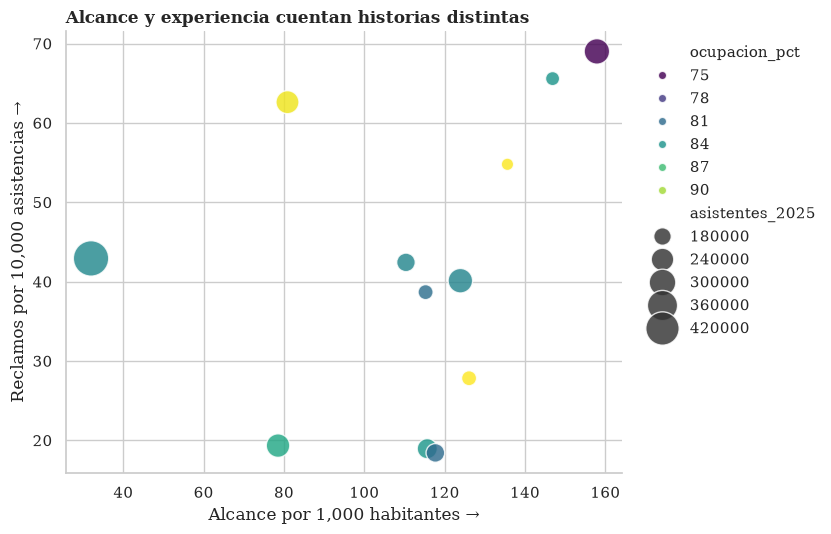

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
d = pd.read_csv('../data/caso4_impacto_departamental_chasquifest.csv')
x, y = d['alcance_por_1000_hab'], d['reclamos_por_10000_asistencias']; sizes = 180 + 900*d['asistentes_2025']/d['asistentes_2025'].max()
sns.set_theme(style='whitegrid', font='serif')
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(data=d, x='alcance_por_1000_hab', y='reclamos_por_10000_asistencias', size='asistentes_2025', hue='ocupacion_pct', sizes=(80,650), palette='viridis', alpha=.82, edgecolor='white', linewidth=1, ax=ax)
ax.set_xlabel('Alcance por 1,000 habitantes →'); ax.set_ylabel('Reclamos por 10,000 asistencias →')
ax.set_title('Alcance y experiencia cuentan historias distintas', loc='left', fontweight='bold')
ax.legend(title='', frameon=False, bbox_to_anchor=(1.02,1), loc='upper left'); sns.despine()
plt.tight_layout(); plt.savefig('fig4_matriz_decision_sedes.png', dpi=130, bbox_inches='tight'); plt.show()
